# Error bucket analysis
Extends the deployment benchmark (`05`) with error attribution. Joins the
per-image `is_smiling()` predictions (`outputs/benchmark_results.csv`) with the
per-image image-quality stats (brightness, blur) and original face-count
(`detections_raw.pkl`, which carries those fields for **all** 3999 images,
including the 0-face / multi-face ones excluded from `dataset_clean.pkl`).

> Note: a `dataset_with_stats.pkl` artifact does not exist in `data/cache/`; the
> brightness / blur / n_faces fields named there live in
> `data/cache/detections_raw.pkl`, which is used here.

In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.offsetbox as mbo

PROJECT_ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
CACHE_DIR = PROJECT_ROOT / "data" / "cache"
OUT_DIR = PROJECT_ROOT / "outputs"
EDA_DIR = PROJECT_ROOT / "data" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

res = pd.read_csv(OUT_DIR / "benchmark_results.csv")
stats = pd.read_pickle(CACHE_DIR / "detections_raw.pkl")[["filename", "brightness", "blur"]]

data = res.merge(stats, on="filename", how="left")
assert len(data) == 823 and data[["brightness", "blur"]].notna().all().all()
data["correct"] = (data["label"] == data["prediction"]).astype(int)
print(f"Joined {len(data)} predictions with image stats (0 unmatched).")

Joined 823 predictions with image stats (0 unmatched).


### Accuracy by image-quality tercile
Brightness (mean luminance) and blur (Laplacian variance) are each cut into
terciles (low / medium / high) across the full test set, then accuracy reported
in each bucket.

In [2]:
rows = []
for col, label in [("brightness", "Brightness"), ("blur", "Blur")]:
    data["_bucket"] = pd.qcut(data[col], 3, labels=["low", "medium", "high"])
    for b in ["low", "medium", "high"]:
        sub = data[data["_bucket"] == b]
        rows.append({
            "metric": label,
            "bucket": b,
            "range": f"{sub[col].min():.1f} - {sub[col].max():.1f}",
            "correct": int(sub["correct"].sum()),
            "total": len(sub),
            "accuracy": sub["correct"].mean(),
        })
bucket_tab = pd.DataFrame(rows).drop(columns="range")
print(bucket_tab.to_string(index=False))
print()
print("Overall accuracy: {:.4f}".format(data["correct"].mean()))

    metric bucket  correct  total  accuracy
Brightness    low      234    275  0.850909
Brightness medium      232    274  0.846715
Brightness   high      230    274  0.839416
      Blur    low      237    275  0.861818
      Blur medium      239    274  0.872263
      Blur   high      220    274  0.802920

Overall accuracy: 0.8457


### 0-face / multi-face subsets
`is_smiling()` returns `False` for anything that is not exactly one face. For the
29 hard images this is **correct per-spec** — but where the ground-truth label
was a *true smile* in a multi-face image, the spec-correct reject is counted as
a false negative by the label. Those are the "correctly-per-spec but
incorrectly-per-label" rejections.

In [3]:
hard = data[data["n_faces"] != 1].copy()
zero = data[data["n_faces"] == 0]
multi = data[data["n_faces"] >= 2]

print("--- 0-face subset (n_faces == 0) ---")
print(f"images={len(zero)}, all classified False: {(zero['prediction'] == 0).all()}")
print(f"accuracy vs label = {(zero['correct']).mean():.3f} ({int(zero['correct'].sum())}/{len(zero)}) "
      f"| labels: {zero['label'].value_counts().to_dict()}")
print()
print("--- multi-face subset (n_faces >= 2) ---")
print(f"images={len(multi)}")
print("predictions all False:", bool((multi['prediction'] == 0).all()))
acc_multi = multi["correct"].mean()
print(f"accuracy vs label = {acc_multi:.3f} ({int(multi['correct'].sum())}/{len(multi)})")
n_true_smile = int((multi["label"] == 1).sum())
print(f"TRUE SMILE images correctly-per-spec but incorrectly-per-label REJECTED = {n_true_smile}")
print(f"  (of those {len(multi)} multi-face images, {n_true_smile} held a genuine smile "
      f"that is_smiling() is spec-defined to refuse; per-label they are FNs)")
print(f"  non-smile multi-face images = {int((multi['label'] == 0).sum())} (all correctly rejected)")

--- 0-face subset (n_faces == 0) ---
images=0, all classified False: True
accuracy vs label = nan (0/0) | labels: {}

--- multi-face subset (n_faces >= 2) ---
images=28
predictions all False: True
accuracy vs label = 0.286 (8/28)
TRUE SMILE images correctly-per-spec but incorrectly-per-label REJECTED = 20
  (of those 28 multi-face images, 20 held a genuine smile that is_smiling() is spec-defined to refuse; per-label they are FNs)
  non-smile multi-face images = 8 (all correctly rejected)


### Misclassification grid
12 misclassified single-face test images (6 false positives + 6 false negatives)
with predicted label and the model's feature values as titles. The 29 hard
0-face / multi-face images carry no landmarks, hence no feature values, so they
are excluded from this figure.

single-face misclassifications available: 107 (FP 53 / FN 54)


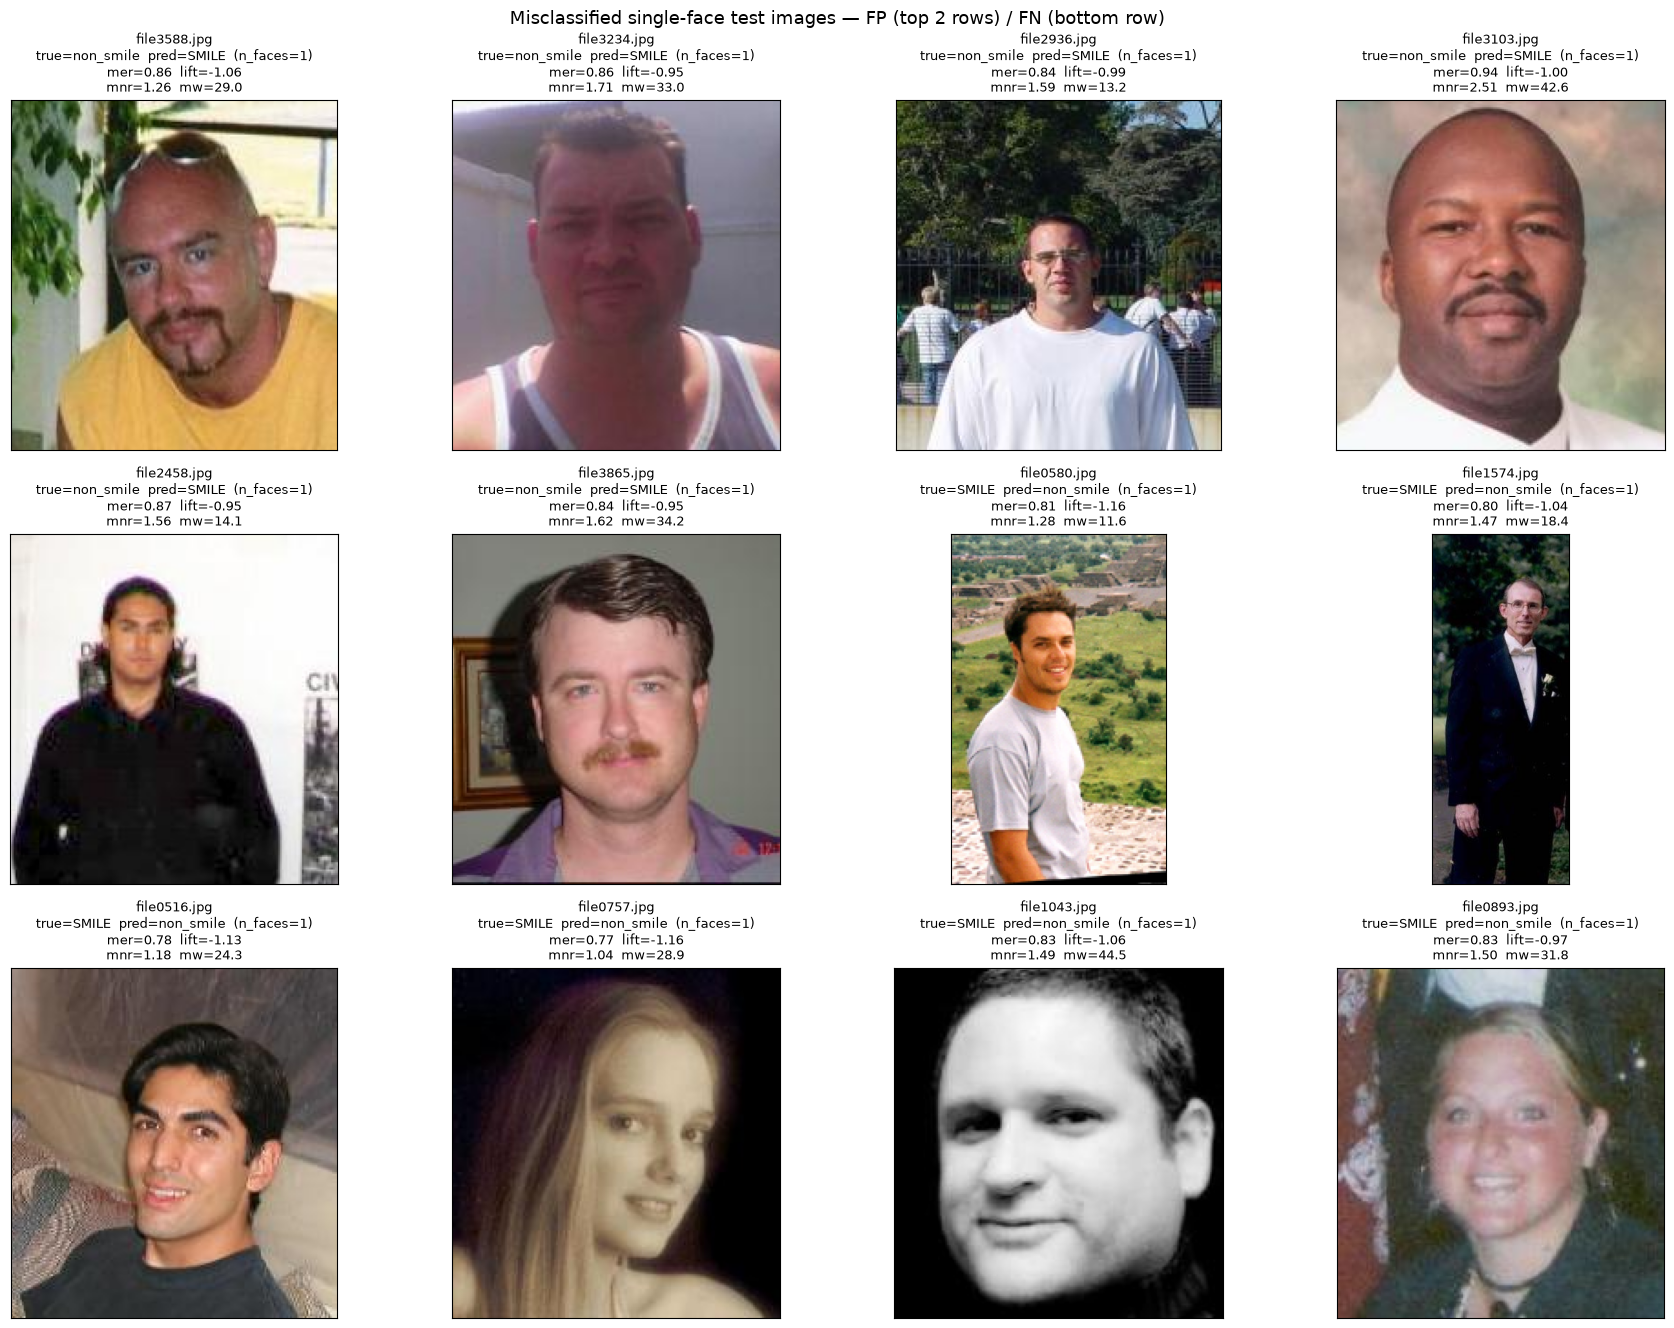

Saved -> outputs/misclassified_grid.png and data/eda/misclassified_grid.png


In [4]:
feat = pd.read_pickle(CACHE_DIR / "features.pkl")[
    ["filename", "mouth_eye_ratio", "mouth_vertical_lift", "mouth_nose_ratio", "mouth_width"]
]
j = data[data["n_faces"] == 1].merge(feat, on="filename", how="left")
mis = j[j["label"] != j["prediction"]].copy()
print(f"single-face misclassifications available: {len(mis)} "
      f"(FP {int((mis['label']==0).sum())} / FN {int((mis['label']==1).sum())})")

fp = mis[mis["label"] == 0].head(6)
fn = mis[mis["label"] == 1].head(6)
grid = pd.concat([fp, fn], ignore_index=True)

fig, axes = plt.subplots(3, 4, figsize=(18, 13.5))
glyph = {0: "non_smile", 1: "SMILE"}
for ax, (_, r) in zip(axes.ravel(), grid.iterrows()):
    img = cv2.imread(r["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])
    title = (f"{r['filename']}\n"
             f"true={glyph[int(r['label'])]}  pred={glyph[int(r['prediction'])]}  "
             f"(n_faces={int(r['n_faces'])})\n"
             f"mer={r['mouth_eye_ratio']:.2f}  lift={r['mouth_vertical_lift']:.2f}\n"
             f"mnr={r['mouth_nose_ratio']:.2f}  mw={r['mouth_width']:.1f}")
    ax.set_title(title, fontsize=9)
fig.suptitle("Misclassified single-face test images — FP (top 2 rows) / FN (bottom row)",
             fontsize=13)
plt.tight_layout()
plt.savefig(EDA_DIR / "misclassified_grid.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved -> data/eda/misclassified_grid.png")